# Import Libraries


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error , r2_score
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore')

from IPython.display import HTML
shell = get_ipython()
def adjust_font_size():
  display(HTML('''<style>
    body {
      font-size: 20px;
    }
  '''))

if adjust_font_size not in shell.events.callbacks['pre_execute']:
  shell.events.register('pre_execute', adjust_font_size)

# Download Datasets

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"tasneembinmahmood","key":"f4ba9275c5e38a356a983a4177b408d7"}'}

In [3]:
import os
import shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)
!pip install -q kaggle

In [4]:
!kaggle datasets download -d shibumohapatra/house-price

Dataset URL: https://www.kaggle.com/datasets/shibumohapatra/house-price
License(s): GNU Lesser General Public License 3.0


In [5]:
!unzip -q house-price.zip

# Read Dataset

In [6]:
df = pd.read_csv("/content/1553768847-housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [7]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1UxK_pJAEiT6ph0GYjVOOSIIbyjVnN7TuEN_YNZYwKro/edit#gid=0


In [8]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
ocean_proximity,0
median_house_value,0


# Taking Care of Missing Data

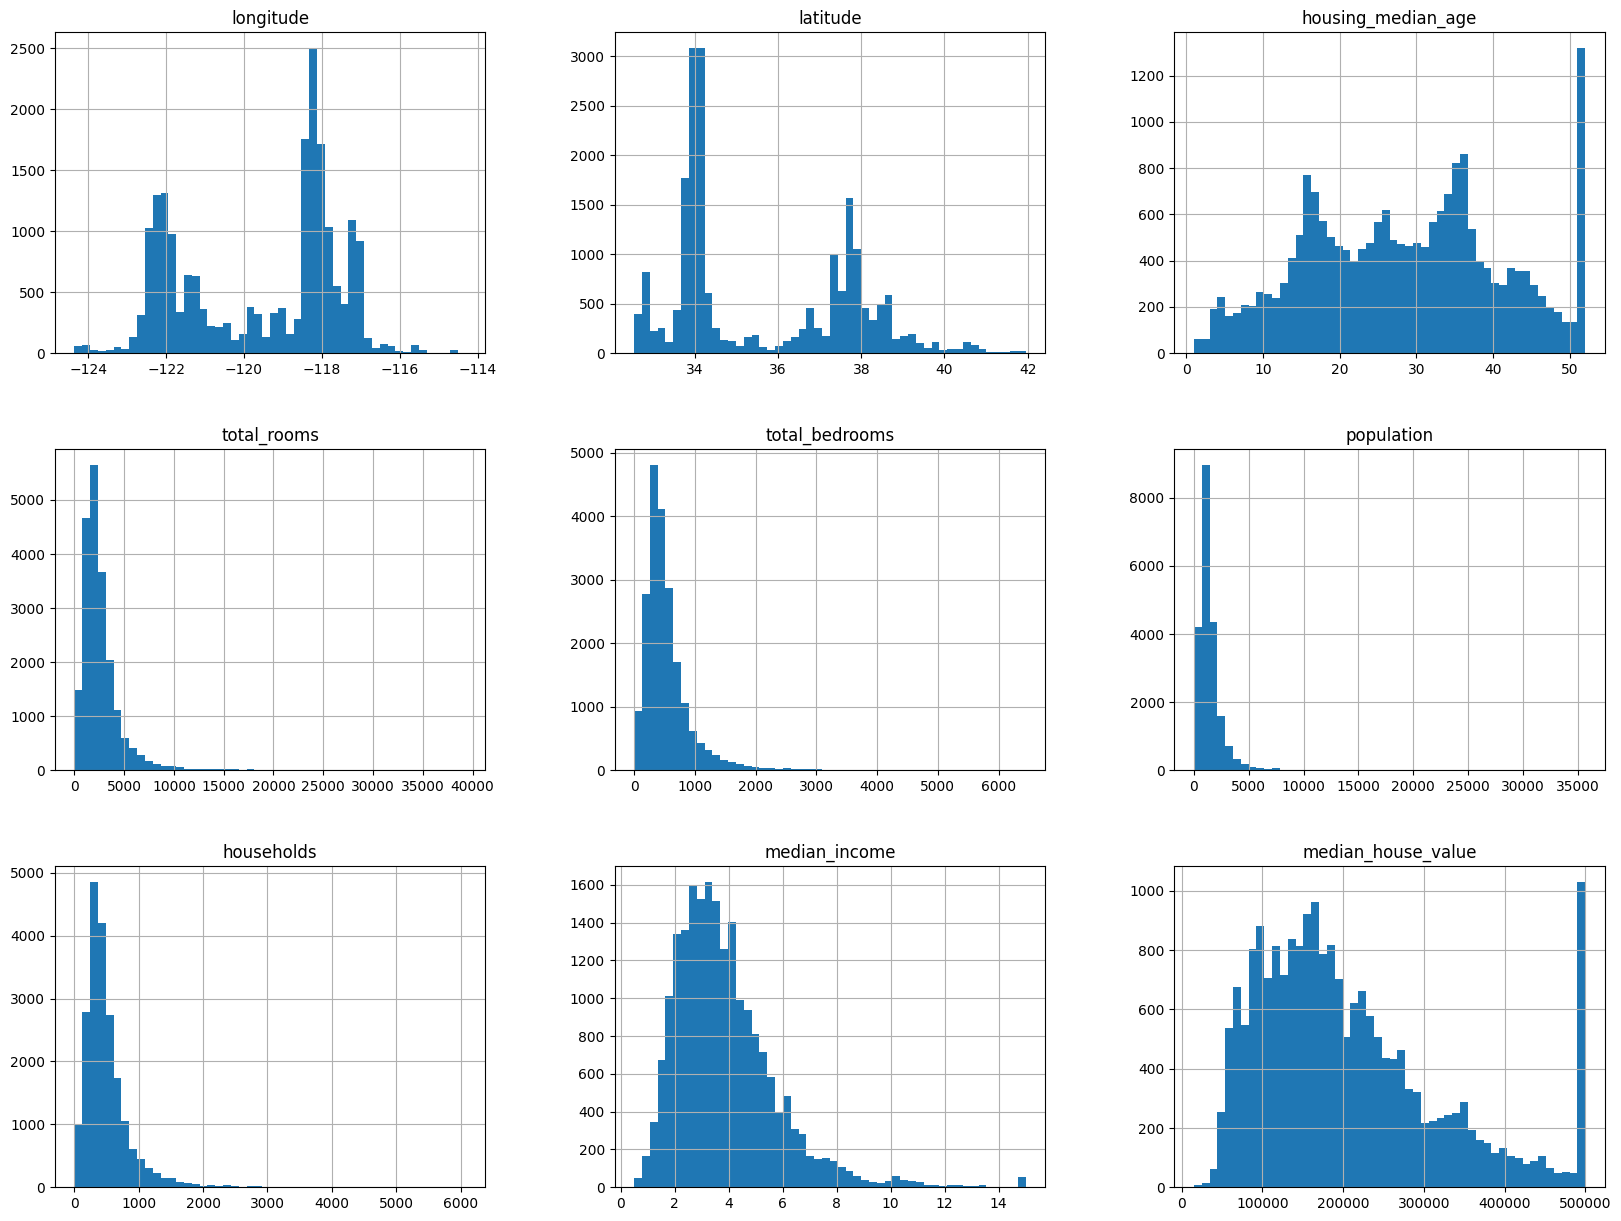

In [9]:
df["total_bedrooms"].fillna(df["total_bedrooms"].mean(), inplace=True)
df.columns
df.hist(bins=50, figsize=(20, 15))
plt.show()

# Encoding Categorical Data

In [10]:
categories = list(df["ocean_proximity"].unique())
ocean_map = {category: idx for idx, category in enumerate(categories)}
#  1st part : category: idx
#  2nd part :  idx, category in enumerate(categories)
df["ocean_proximity_encoded"] = df["ocean_proximity"].map(ocean_map)
df = df.drop(columns=["ocean_proximity"])

# Feature Scaling

In [11]:
#  FEATURE ENGINEERING

# 1. Average number of rooms per household
df["rooms_per_household"] = df["total_rooms"] / df["households"]

# 2. Proportion of bedrooms to total rooms (how many rooms are bedrooms)
df["bedrooms_per_room"] = df["total_bedrooms"] / df["total_rooms"]

# 3. Average number of people per household
df["population_per_household"] = df["population"] / df["households"]

# 4. Average number of households per person (inverse of population density per household)
df["households_per_population"] = df["households"] / df["population"]

# 5. Number of rooms per person (how crowded the housing is)
df["rooms_per_person"] = df["total_rooms"] / df["population"]

# 6. Median income per household (although median_income is already per household, this can serve as a proxy)
df["income_per_household"] = df["median_income"] / df["households"]

# 7. Number of bedrooms per household (could signal family size or house type)
df["bedrooms_per_household"] = df["total_bedrooms"] / df["households"]

# 8. Explicit average household size (redundant with population_per_household but clearer name)
df["avg_household_size"] = df["population"] / df["households"]


# HeatMap

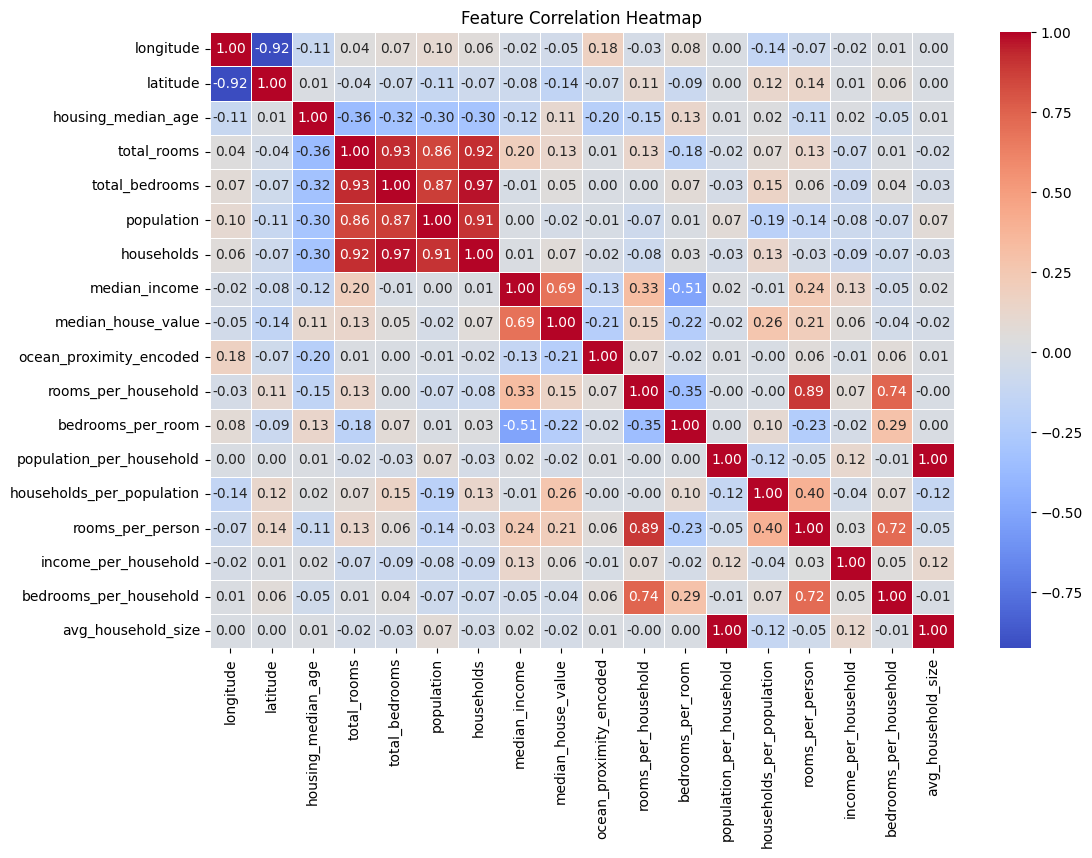

In [12]:
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Create a heatmap using seaborn

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f",linewidths=0.5
)
plt.title("Feature Correlation Heatmap")
plt.show()

# Scatter Plot

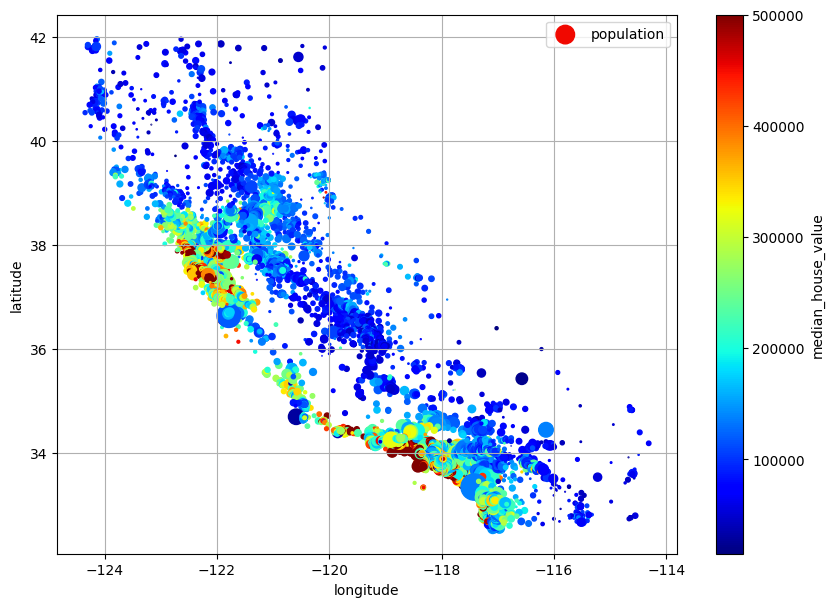

In [13]:
df.plot(kind="scatter", x="longitude", y="latitude", grid=True,
             s=df["population"] / 100, label="population",
             c="median_house_value", cmap="jet", colorbar=True,
             legend=True, sharex=False, figsize=(10, 7))
plt.show()

# Creating New Feature

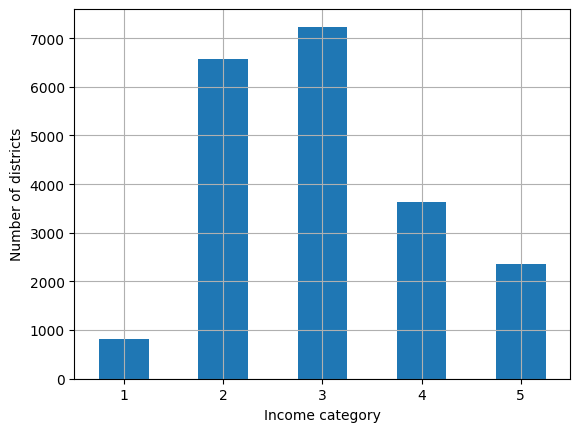

In [14]:
# Create income categories and plot distribution
df["income_cat"] = pd.cut(df["median_income"],
                         bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                         labels=[1, 2, 3, 4, 5])

# Plot income category distribution
df["income_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Income category")
plt.ylabel("Number of districts")
plt.show()
"""
Bins median income into 5 categories and visualizes distribution:
1: <$15k, 2: $15k-30k, 3: $30k-45k, 4: $45k-60k, 5: >$60k
Shows count of districts in each income bracket
"""

df = df.drop(columns=["latitude"])
df = df.drop(columns=["longitude"])

# Training the Model on Linear Regression

## Splitting the Data into Training set and Test set

In [15]:
strat_train_set, strat_test_set = train_test_split(
    df, test_size=0.2, stratify=df["income_cat"],shuffle=True, random_state=1215)

## Dropping target variables from the Train Data

In [16]:
# Drop the target and non-numeric columns from training data
train_data = strat_train_set.drop(["median_house_value", "income_cat"], axis=1)

# Extract the target (what we want to predict)
train_labels = strat_train_set["median_house_value"].copy()

## Creating Pipeline

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Create a pipeline to fill missing values and scale the features
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler())
])

# Fit and transform training data
train_prepared = num_pipeline.fit_transform(train_data)

## Train The Model

In [19]:
from sklearn.linear_model import LinearRegression

# Create and train the model
lin_reg = LinearRegression()
lin_reg.fit(train_prepared, train_labels)

LinearRegression()

## Predicting Results Based on Train Data

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Make predictions on the training set
train_predictions = lin_reg.predict(train_prepared)

# Calculate metrics
lin_mse = mean_squared_error(train_labels, train_predictions)
lin_rmse = lin_mse ** 0.5
lin_mae = mean_absolute_error(train_labels, train_predictions)
lin_r2 = r2_score(train_labels, train_predictions)

# Print results
print("Linear Regression Training Performance")
print(f"Root Mean Squared Error (RMSE): {lin_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {lin_mae:.2f}")
print(f"R-Squared (R²): {lin_r2:.4f}")

Linear Regression Training Performance
Root Mean Squared Error (RMSE): 71609.52
Mean Absolute Error (MAE): 52560.52
R-Squared (R²): 0.6118


## Dropping Target Variables from the Test Data

In [32]:
test_data = strat_test_set.drop(["median_house_value", "income_cat"], axis=1)
test_labels = strat_test_set["median_house_value"].copy()
test_prepared = num_pipeline.transform(test_data)

## Predicting Results Based on Test Set

In [33]:
# Make predictions on the test set
test_predictions = lin_reg.predict(test_prepared)

# Calculate evaluation metrics
test_mse = mean_squared_error(test_labels, test_predictions)
test_rmse = test_mse ** 0.5
test_mae = mean_absolute_error(test_labels, test_predictions)
test_r2 = r2_score(test_labels, test_predictions)

# Print test results
print("🧪 Linear Regression Test Performance")
print(f"Root Mean Squared Error (RMSE): {test_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {test_mae:.2f}")
print(f"R-Squared (R²): {test_r2:.4f}")

🧪 Linear Regression Test Performance
Root Mean Squared Error (RMSE): 73680.88
Mean Absolute Error (MAE): 54188.55
R-Squared (R²): 0.6050


## Visualizing The Results

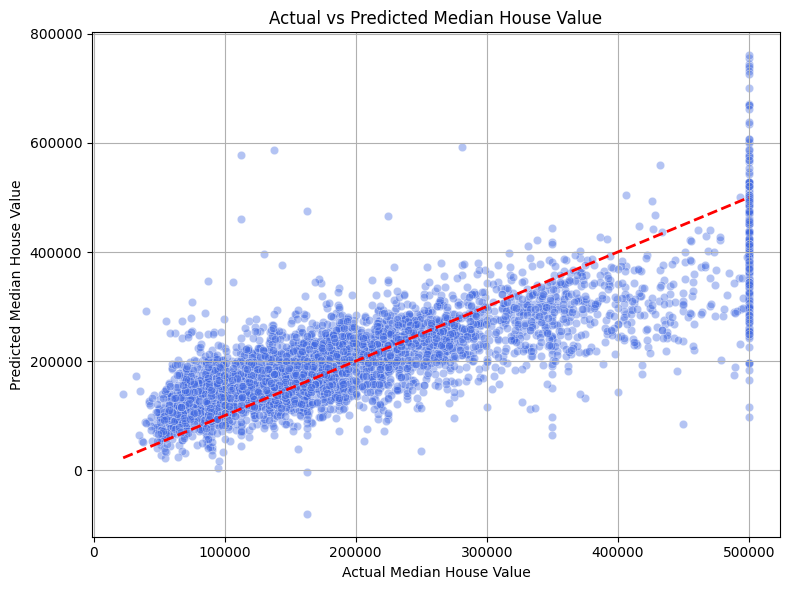

In [34]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=test_labels, y=test_predictions ,alpha = 0.4 , color ="royalblue")
plt.plot([test_labels.min(),test_labels.max()],
         [test_labels.min(),test_labels.max()],
         color='red', linestyle='--', linewidth=2
         )
plt.title("Actual vs Predicted Median House Value")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.grid(True)
plt.tight_layout()
plt.show()

# Training Model on Random Forest Regression

## Dropping target variables from the Train Data

In [38]:
train_features = strat_train_set.drop(["median_house_value", "income_cat"], axis=1)
train_labels = strat_train_set["median_house_value"].copy()

## Train the Model

In [39]:
# Initialize the model
forest_reg = RandomForestRegressor(n_estimators=100, random_state=1215)

# Train the model
forest_reg.fit(train_features, train_labels)

RandomForestRegressor(random_state=1215)

## Predicting Results Based on Train Data

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

forest_predictions = forest_reg.predict(train_features)

# Evaluate the model
forest_mse = mean_squared_error(train_labels, forest_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_mae = mean_absolute_error(train_labels, forest_predictions)
forest_r2 = r2_score(train_labels, forest_predictions)

# Print evaluation metrics
print("🌲 Random Forest Regressor Test Performance")
print(f"Root Mean Squared Error (RMSE): {forest_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {forest_mae:.2f}")
print(f"R-Squared (R²): {forest_r2:.4f}")

🌲 Random Forest Regressor Test Performance
Root Mean Squared Error (RMSE): 21966.94
Mean Absolute Error (MAE): 15190.04
R-Squared (R²): 0.9635


## Dropping Target Variables from the Test Data

In [42]:
test_features = strat_test_set.drop(["median_house_value", "income_cat"], axis=1)
test_labels = strat_test_set["median_house_value"].copy()

## Predicting Results Based on Test Set

In [46]:
forest_predictions = forest_reg.predict(test_features)

# Evaluate the model
forest_mse = mean_squared_error(test_labels, forest_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_mae = mean_absolute_error(test_labels, forest_predictions)
forest_r2 = r2_score(test_labels, forest_predictions)

# Print evaluation metrics
print("🌲 Random Forest Regressor Test Performance")
print(f"Root Mean Squared Error (RMSE): {forest_rmse:.2f}")
print(f"Mean Absolute Error (MAE): {forest_mae:.2f}")
print(f"R-Squared (R²): {forest_r2:.4f}")

🌲 Random Forest Regressor Test Performance
Root Mean Squared Error (RMSE): 60439.95
Mean Absolute Error (MAE): 41949.50
R-Squared (R²): 0.7342


## Visualizing The Results

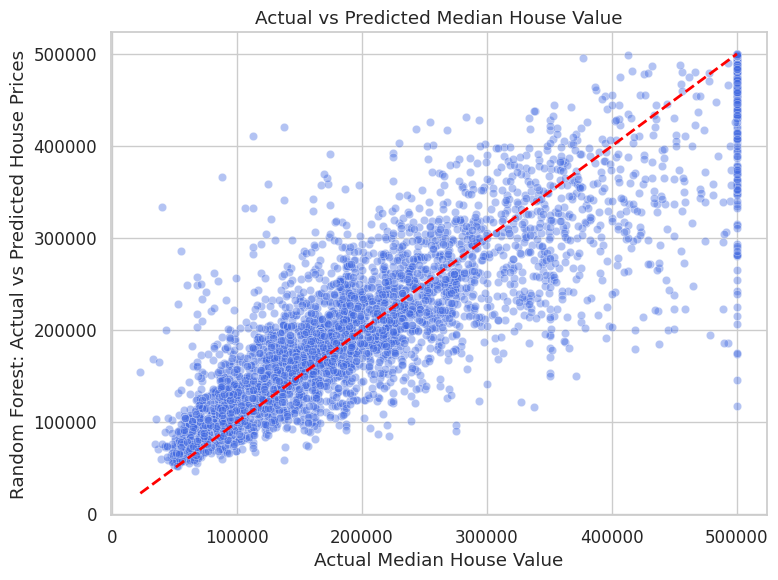

In [64]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=test_labels, y=forest_predictions ,alpha = 0.4 , color ="royalblue")
plt.plot([test_labels.min(),test_labels.max()],
         [test_labels.min(),test_labels.max()],
         color='red', linestyle='--', linewidth=2
         )
plt.title("Actual vs Predicted Median House Value")
plt.xlabel("Actual Median House Value")
plt.ylabel("Random Forest: Actual vs Predicted House Prices")
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparing Both Models

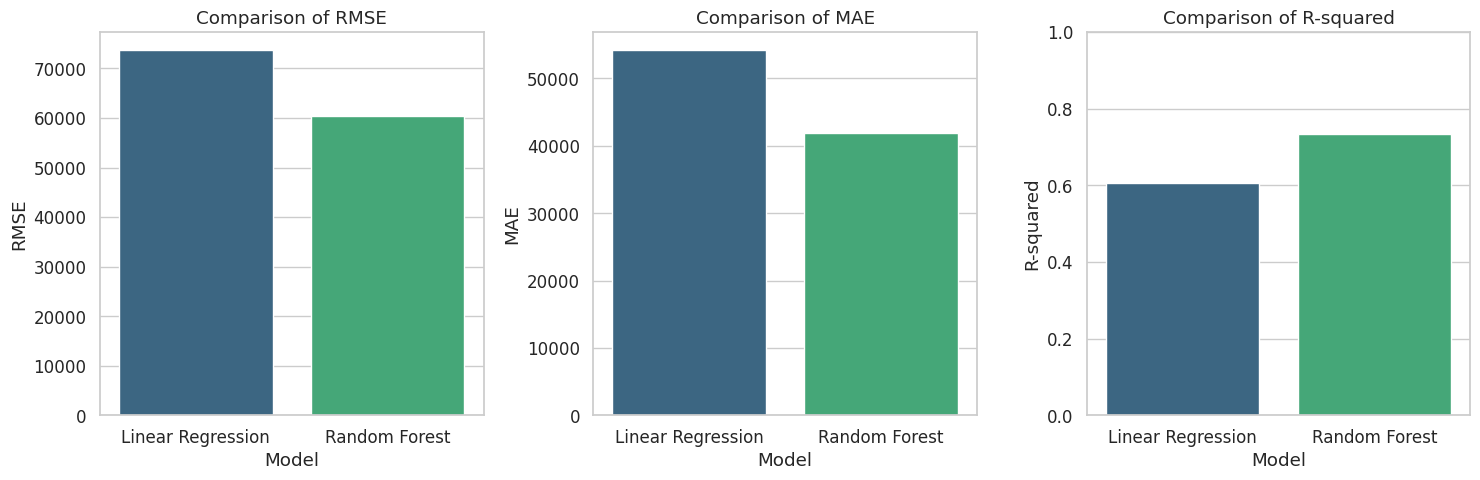

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Collect metrics for both models (using test set results)

models = ['Linear Regression', 'Random Forest']
rmse_values = [test_rmse, forest_rmse]
mae_values = [test_mae, forest_mae]
r2_values = [test_r2, forest_r2]

metrics_df = pd.DataFrame({
    'Model': models,
    'RMSE': rmse_values,
    'MAE': mae_values,
    'R-squared': r2_values
})

# Plotting the bar charts

plt.figure(figsize=(15, 5))

# RMSE Bar Chart

plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='RMSE', data=metrics_df, palette='viridis')
plt.title('Comparison of RMSE')
plt.ylabel('RMSE')

# MAE Bar Chart

plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='MAE', data=metrics_df, palette='viridis')
plt.title('Comparison of MAE')
plt.ylabel('MAE')

# R-squared Bar Chart

plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='R-squared', data=metrics_df, palette='viridis')
plt.title('Comparison of R-squared')
plt.ylabel('R-squared')
plt.ylim(0, 1) # R-squared is typically between 0 and 1

plt.tight_layout()
plt.show()

# Overall Performance

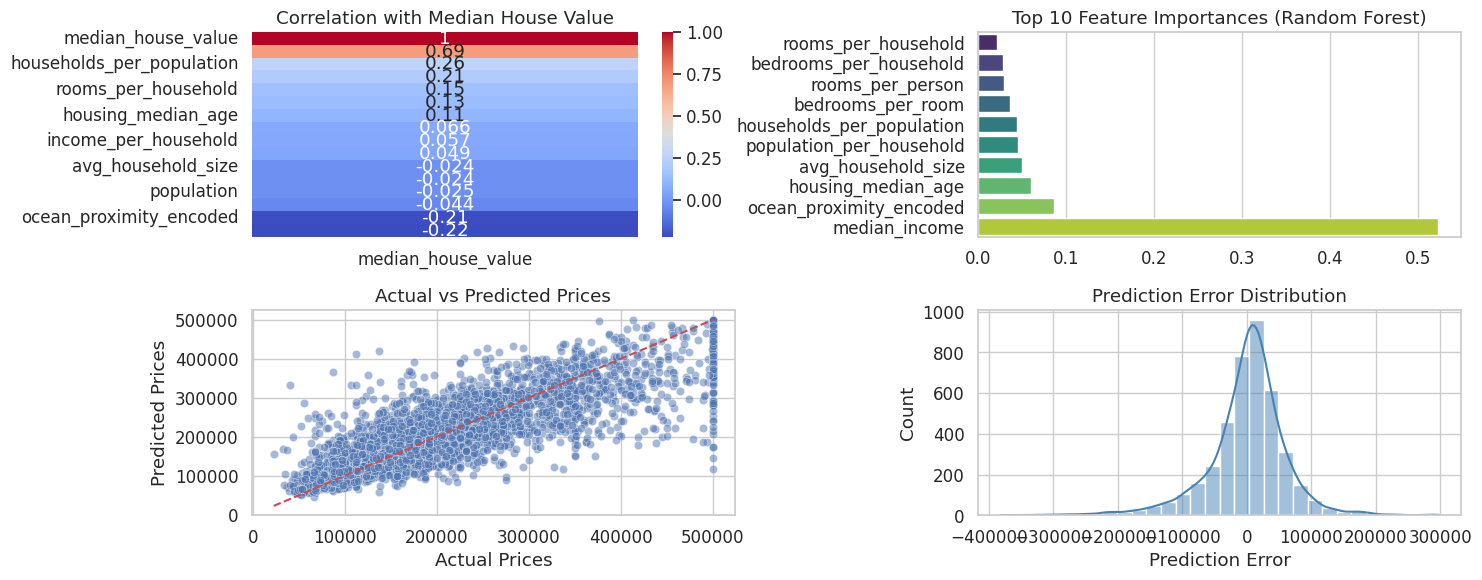

In [63]:
sns.set(style="whitegrid", font_scale=1.1)

# 1. Correlation Heatmap
plt.figure(figsize=(15, 6))
plt.subplot(2, 2, 1)
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix[["median_house_value"]].sort_values(by="median_house_value", ascending=False),
            annot=True, cmap="coolwarm")
plt.title("Correlation with Median House Value")

# 2. Feature Importances (Random Forest)
plt.subplot(2, 2, 2)
importances = forest_reg.feature_importances_
features = list(train_features.columns)
sorted_idx = np.argsort(importances)[-10:]  # top 10 features
sns.barplot(x=importances[sorted_idx], y=np.array(features)[sorted_idx], palette="viridis")
plt.title("Top 10 Feature Importances (Random Forest)")

# 3. Actual vs Predicted Prices
plt.subplot(2, 2, 3)
sns.scatterplot(x=test_labels, y=forest_predictions, alpha=0.5)
plt.plot([test_labels.min(), test_labels.max()],
         [test_labels.min(), test_labels.max()], 'r--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

# 4. Prediction Error Distribution
plt.subplot(2, 2, 4)
errors = forest_predictions - test_labels
sns.histplot(errors, kde=True, bins=30, color="steelblue")
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")

plt.tight_layout()
plt.show()